# Bottleneck Detection

This notebook applies a rule-based approach to detect potential traffic bottlenecks. Signals may include dense traffic, a high share of heavy vehicles, sudden drops, or anomalies that suggest recurring congestion or infrastructure-related issues.

### Step 6: Detect bottlenecks
This section applies the rule-based logic for identifying potential traffic bottlenecks.

In [ ]:
# Detect potential traffic bottlenecks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import zscore

plt.style.use("ggplot")

In [5]:
# Detect potential traffic bottlenecks
df = pd.read_csv("../data/traffic_cleaned_final.csv")

C:\Users\vikhy\AppData\Local\Temp\ipykernel_7948\4247965084.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


In [8]:
# Detect potential traffic bottlenecks
ROAD = 6

road = df[df["Str_Nr"] == ROAD].copy()

In [9]:
# Detect potential traffic bottlenecks
road = road[
    [
        "Jahr",
        "DZ_Name",
        "Betriebs_km",
        "DTV_Kfz_W_Q",
        "DTV_SV_W_Q",
        "pSV_W_Q",
        "Anz_Fs_Q",
        "Koor_WGS84_N",
        "Koor_WGS84_E",
        "Anmerkungen"
    ]
]

In [10]:
# Detect potential traffic bottlenecks
road = road.dropna(
    subset=[
        "Betriebs_km",
        "DTV_Kfz_W_Q",
        "Anz_Fs_Q"
    ]
)

print(road.shape)

(891, 10)


In [ ]:
#sort stations by betriebs_km and year
road = road.sort_values(
    by=[
        "Jahr",
        "Betriebs_km"
    ]
)

In [12]:
# Detect potential traffic bottlenecks
road["Traffic_Density"] = (
    road["DTV_Kfz_W_Q"] /
    road["Anz_Fs_Q"]
)

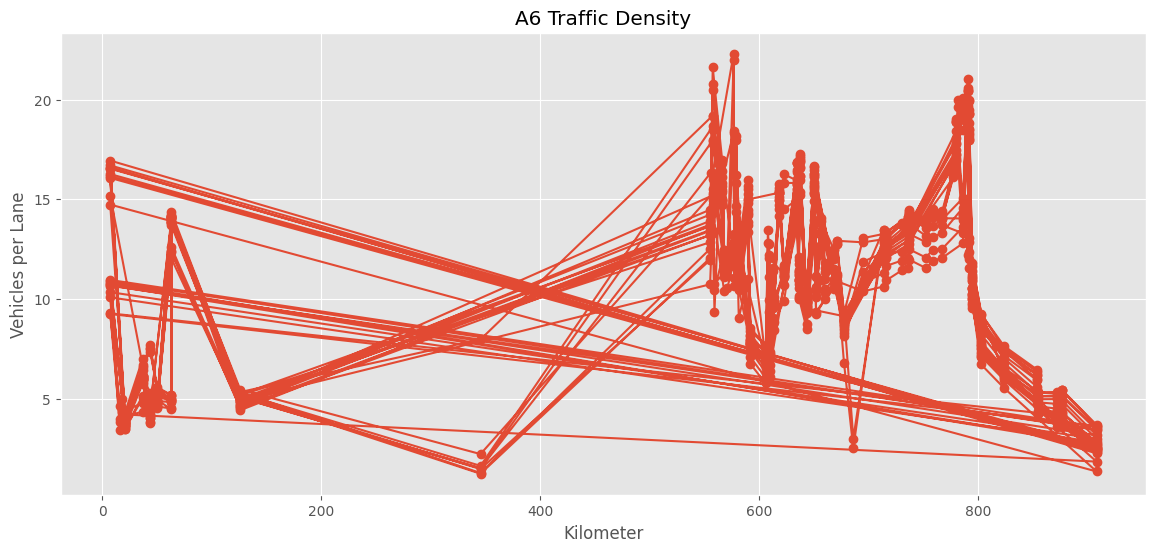

In [ ]:
# Detect potential traffic bottlenecks
#AI usage : give me code to create a chart to visualize traffic density along the road A6
plt.figure(figsize=(14,6))

plt.plot(
    road["Betriebs_km"],
    road["Traffic_Density"],
    marker="o"
)

plt.title(f"A{ROAD} Traffic Density")

plt.xlabel("Kilometer")

plt.ylabel("Vehicles per Lane")

plt.grid(True)

plt.show()

In [14]:

#traffic drop
road["Previous_Traffic"] = (
    road
    .groupby("Jahr")["DTV_Kfz_W_Q"]
    .shift(1)
)

AI usage : helped me debug the errors in bottleneck code below and suggest improvements in quality of code.


AI prompt : help me writing the code for detection of traffic bottlenecks and let me know if changes

In [15]:
# Detect potential traffic bottlenecks
road["Traffic_Drop"] = (
    road["Previous_Traffic"] -
    road["DTV_Kfz_W_Q"]
)

In [16]:
# Detect potential traffic bottlenecks
road["Drop_Percent"] = (
    road["Traffic_Drop"] /
    road["Previous_Traffic"]
) * 100

In [17]:
# Detect potential traffic bottlenecks
road["Drop_Flag"] = (
    road["Drop_Percent"] > 30
)

In [18]:
#traffic outlier
road["Traffic_Z"] = zscore(
    road["DTV_Kfz_W_Q"]
)

In [19]:
# Detect potential traffic bottlenecks
road["Traffic_Outlier"] = (
    abs(road["Traffic_Z"]) > 2
)

In [20]:
#heavy truck
limit = road["pSV_W_Q"].quantile(0.90)

road["Truck_Flag"] = (
    road["pSV_W_Q"] > limit
)

In [21]:
#construction detection
road["Construction"] = (
    road["Anmerkungen"]
    .fillna("")
    .str.contains(
        "Netzmodernisierung|Baustelle",
        case=False,
        regex=True
    )
)

In [22]:
#risk score
road["Risk"] = 0

In [23]:
# Detect potential traffic bottlenecks
road.loc[
    road["Drop_Flag"],
    "Risk"
] += 2

In [24]:
# Detect potential traffic bottlenecks
road.loc[
    road["Traffic_Outlier"],
    "Risk"
] += 2

In [25]:
# Detect potential traffic bottlenecks
road.loc[
    road["Construction"],
    "Risk"
] += 2

In [ ]:
#classification using scores
def classify(score):

    if score >= 5:
        return "Critical"

    elif score >= 3:
        return "High"

    elif score >= 2:
        return "Medium"

    elif score >= 1:
        return "Low"

    return "Normal"

road["Risk_Level"] = road["Risk"].apply(classify)

In [27]:
# Detect potential traffic bottlenecks
result = road[
    [
        "DZ_Name",
        "Betriebs_km",
        "Traffic_Density",
        "Drop_Percent",
        "pSV_W_Q",
        "Risk",
        "Risk_Level"
    ]
]

result.sort_values(
    "Risk",
    ascending=False
).head(30)

,DZ_Name,Betriebs_km,Traffic_Density,Drop_Percent,pSV_W_Q,Risk,Risk_Level
23884,AK Nürnberg-Ost (O),794.7,10.179500,45.046966,25.7,4,High
22424,Miesau,643.3,9.781250,60.724181,20.9,4,High
22425,Neckarsulm 1,637.1,16.602667,-117.264995,23.0,4,High
3440,Posthof,36.9,4.343500,47.462957,9.2,4,High
3433,Grasdorf,16.2,3.410250,77.453265,12.1,4,High
23044,Sarstedt,20.8,3.793000,77.613504,7.0,4,High
21559,Sarstedt,20.8,3.691750,77.895036,6.9,4,High
20933,Miesau,643.3,9.647500,61.904856,20.3,4,High
24510,Sarstedt,20.8,3.581500,78.413971,6.8,4,High
20934,Neckarsulm 1,637.1,16.883167,-126.154224,22.8,4,High


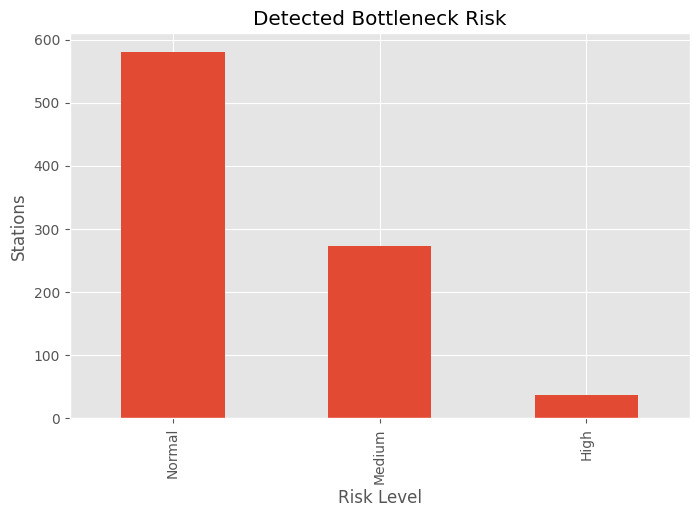

In [ ]:
#visualization of risk levels
#AI usage : I want to create a bar chart to visualize the risk levels of traffic bottlenecks along the road A6
risk = (
    road["Risk_Level"]
    .value_counts()
)

plt.figure(figsize=(8,5))

risk.plot(
    kind="bar"
)

plt.title(
    "Detected Bottleneck Risk"
)

plt.xlabel("Risk Level")

plt.ylabel("Stations")

plt.show()

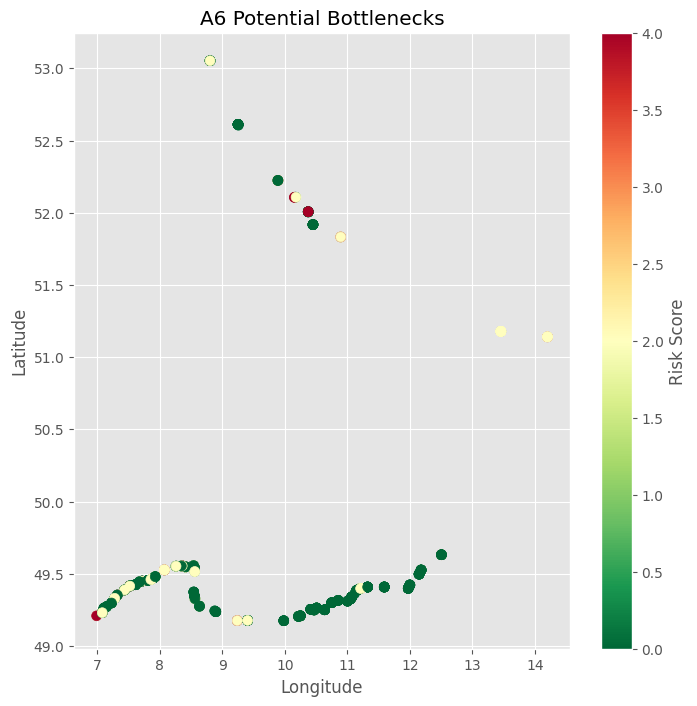

In [29]:
#map
plt.figure(figsize=(8,8))

plt.scatter(
    road["Koor_WGS84_E"],
    road["Koor_WGS84_N"],
    c=road["Risk"],
    cmap="RdYlGn_r",
    s=50
)

plt.colorbar(
    label="Risk Score"
)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title(f"A{ROAD} Potential Bottlenecks")

plt.show()

In [30]:
#top 10 bottlenecks
top10 = (
    road
    .sort_values("Risk", ascending=False)
    .head(10)
)

top10[
    [
        "DZ_Name",
        "Betriebs_km",
        "Risk",
        "Risk_Level"
    ]
]

,DZ_Name,Betriebs_km,Risk,Risk_Level
23884,AK Nürnberg-Ost (O),794.7,4,High
22424,Miesau,643.3,4,High
22425,Neckarsulm 1,637.1,4,High
3440,Posthof,36.9,4,High
3433,Grasdorf,16.2,4,High
23044,Sarstedt,20.8,4,High
21559,Sarstedt,20.8,4,High
20933,Miesau,643.3,4,High
24510,Sarstedt,20.8,4,High
20934,Neckarsulm 1,637.1,4,High


In [ ]:
#AI usage : simiilarily like last notebook give me summary for this
# Detect potential traffic bottlenecks
print("="*60)
print("BOTTLENECK DETECTION REPORT")
print("="*60)

print(f"Road Analysed      : A{ROAD}")

print(f"Stations Analysed  : {len(road)}")

print(f"Normal             : {(road['Risk_Level']=='Normal').sum()}")

print(f"Low Risk           : {(road['Risk_Level']=='Low').sum()}")

print(f"Medium Risk        : {(road['Risk_Level']=='Medium').sum()}")

print(f"High Risk          : {(road['Risk_Level']=='High').sum()}")

print(f"Critical Risk      : {(road['Risk_Level']=='Critical').sum()}")

BOTTLENECK DETECTION REPORT
Road Analysed      : A6
Stations Analysed  : 891
Normal             : 581
Low Risk           : 0
Medium Risk        : 273
High Risk          : 37
Critical Risk      : 0
